In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
# displays inside the notebook
%matplotlib inline 

In [2]:
def f(x):
    return 3*x**2 - 5*x + 9

In [3]:
f(2)

11

[109.     100.4375  92.25    84.4375  77.      69.9375  63.25    56.9375
  51.      45.4375  40.25    35.4375  31.      26.9375  23.25    19.9375
  17.      14.4375  12.25    10.4375   9.       7.9375   7.25     6.9375
   7.       7.4375   8.25     9.4375  11.      12.9375  15.25    17.9375
  21.      24.4375  28.25    32.4375  37.      41.9375  47.25    52.9375
  59.      65.4375  72.25    79.4375]


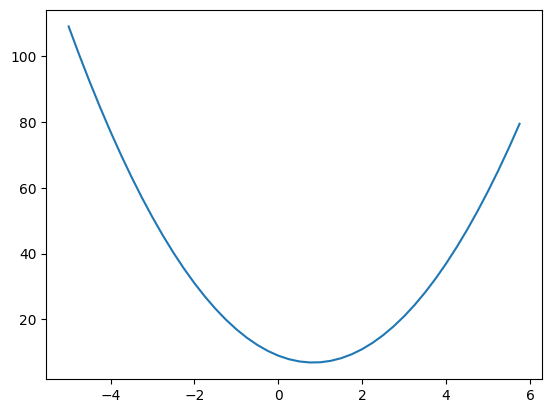

In [4]:
x = np.arange(-5,6,0.25)
y = f(x)
print(y)
plt.plot(x,y)

### Derivative
slope = what is the change in y if i make tiny change in x

In [5]:
h = 0.0000001
x = 4.0

(f(x+h)-f(x))/h

19.00000043519867

In [6]:
h = 0.001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1',d1)
print('d2',d2)
print('slope ',(d2-d1)/h)

d1 4.0
d2 3.997
slope  -3.0000000000001137


In [67]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    
    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self,other):
        return Value(self.data + other.data, (self,other),'+')
    
    def __mul__(self,other):
        return Value(self.data * other.data, (self,other),'*')

# python does not know how to operation basic math operation on two objects

# internally 
# a + b
# a.__add__(b)
# self == a
# other == b

# example
# a*b + c
# (a.__mul__(b)).__add__(c)

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(-1.0, label='c')
print(f"a = {a} b = {b}")
print(type (a))
print(type (a.data))
# a*b
# can call this operation manually too
# (a.__mul__(b)).__add__(c)

e = a*b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0,label='f')
L = d*f; L.label='L'
L

a = Value(data = 2.0) b = Value(data = -3.0)
<class '__main__.Value'>
<class 'float'>


Value(data = 14.0)

In [8]:
b._prev

set()

In [9]:
b._op

''

In [10]:
d._prev

{Value(data = -1.0), Value(data = -6.0)}

In [11]:
d._op

'+'

### visualization

In [49]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name=uid + n._op, label=n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


### Doing manual back propagation

In [38]:
L.grad = 1.0
f.grad = -7.0
d.grad = -2.0

dd/dc ?<br>

d = c+e <br>
(f(x+h)-f(x))/h , as h -> 0<br>
((c+h + e) - (c+e)) / h<br>
1.0 <br><br>

similarly dd/de = 1.0<br>
these are the local derivatives

In [ ]:
# chain rule in calculus
# dl/dc = dl/dd * dd/dc
# dl/dc = -2.0 * 1.0
# dl/dc = -2.0
# dl/de = -2.0

In [72]:
c.grad = -2.0
e.grad = -2.0

In [ ]:
# dl/da = dl/de * de/da = -2.0 * -3.0 = 6.0
# dl/db = -2.0 * 2.0 = -4.0

In [73]:
a.grad = 6.0
b.grad = -4.0

### Diagram

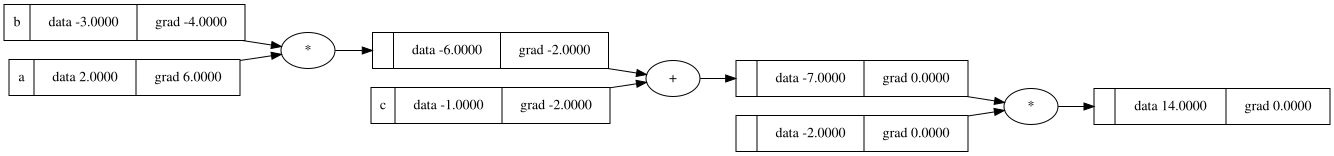

In [74]:
draw_dot(L)

In [78]:
#nudging the output in teh direction of gradient
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
d.data += 0.01*d.grad
e.data += 0.01*e.grad
f.data += 0.01*f.grad

# after updating the gradient
e = a*b
d = e + c
f = Value(-2.0)
L = d*f
print(L.data) 

# we updated weights such that out output L went up from 14.0 -> 14.56480
# think this through we are simply looking at the influence of intermidate numbers on L. Lets say
# increasing the value of d increases L so dl/dd > 0 
# inceasing the calue if e decreases L so dl/de < 0

# now simply we are nudging the values of d and l according to the gradient descent by multiplying a smal learning rate
# d = d + 0.01*(dl/dd) , so our d value inceases by slightly to ifluence +ve L 
# e = e + 0.01*(dl/de) . so our e value decreases by slightly to influence +ve L 

16.3168


In [ ]:
# (venv) ┌─[midori@parrot]─[~/Desktop/Machine-Learning/Nural_Network]
# └──╼ $source /home/midori/Desktop/Machine-Learning/venv/bin/activate

In [43]:
def lol():
    h = 0.001


    e = a*b; e.label='e'
    d = e + c; d.label='d'
    f = Value(-2.0,label='f')
    L = d*f; L.label='L'
    L1 = L.data

    e = a*b; e.label='e'
    d = e + c; d.label='d'; d.data += h
    f = Value(-2.0,label='f')
    L = d*f; L.label='L'
    L2 = L.data

    #derivative(slope) === rise/run
    print((L2-L1)/h)

lol()

-2.000000000000668
